In [1]:
# Install required packages silently
install.packages(
  c("readxl", "tidyquery"),
  quiet = TRUE,
  verbose = FALSE,
  INSTALL_opts = "--no-test-load"
)

also installing the dependency ‘queryparser’




In [2]:
library(readxl)
library(tidyr)
library(tidyquery)
library(ggplot2)

#### Load the dataset

In [5]:
ghg_df <- read_xlsx(path = "sample_data/EDGAR_2025_GHG_booklet_2025.xlsx", sheet ="GHG_by_sector_and_country")

head(ghg_df, 5)

Substance,Sector,EDGAR Country Code,Country,1970,1971,1972,1973,1974,1975,⋯,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CO2,Agriculture,AFG,Afghanistan,0.02922857,0.02922857,0.02922857,0.02922857,0.03996666,0.04530952,⋯,0.11696665,0.16300949,0.31129994,0.16133331,0.15127616,0.06479523,0.04049047,0.05311428,0.05235999,0.05183199
CO2,Agriculture,ALB,Albania,0.11330000,0.11330000,0.11330000,0.11330000,0.11361429,0.11251429,⋯,0.05651904,0.04740476,0.05416190,0.04646190,0.06641904,0.06055238,0.04834761,0.06065714,0.06195619,0.06332173
CO2,Agriculture,ARG,Argentina,0.10434285,0.10434285,0.10434285,0.10434285,0.08721428,0.07731428,⋯,0.89225704,1.38579030,1.27840935,1.59211883,1.70306166,1.92547116,2.07140446,1.94149973,2.03848828,2.15414394
CO2,Agriculture,ARM,Armenia,0.05528820,0.05528820,0.05528820,0.05528820,0.05996644,0.05996644,⋯,0.03394286,0.03944286,0.05248571,0.05107143,0.06102381,0.05583809,0.04462857,0.04180000,0.04198857,0.04218657
CO2,Agriculture,AUS,Australia,0.31114284,0.31114284,0.31114284,0.31114284,0.31114284,0.26819046,⋯,2.32492833,2.54262352,2.94983298,2.13069977,2.27558548,2.66430447,3.25385202,2.86267111,2.81028597,2.79174380


#### Reshape the data (Pivot from wide to long)

In [6]:
melted_df <- ghg_df %>%
  pivot_longer(
    cols = `1970`:`2024`,
    names_to = "Year",
    values_to = "GHG_Total"
  )

# # Ensure Year is numeric for the x-axis
melted_df$Year <- as.integer(melted_df$Year)

head(melted_df, 5)

Substance,Sector,EDGAR Country Code,Country,Year,GHG_Total
<chr>,<chr>,<chr>,<chr>,<int>,<dbl>
CO2,Agriculture,AFG,Afghanistan,1970,0.02922857
CO2,Agriculture,AFG,Afghanistan,1971,0.02922857
CO2,Agriculture,AFG,Afghanistan,1972,0.02922857
CO2,Agriculture,AFG,Afghanistan,1973,0.02922857
CO2,Agriculture,AFG,Afghanistan,1974,0.03996666


#### Filter top 10 sectors by GHG emissions

In [13]:
# Using tidyquery (Direct SQL on R Data Frames)
df_top_10_sectors_by_ghg <- query("
    SELECT Sector, SUM(GHG_Total) AS GHG_Total
    FROM melted_df
    WHERE Country NOT IN ('GLOBAL TOTAL', 'EU27')
    GROUP BY Sector
    ORDER BY GHG_Total
    DESC LIMIT 10
")

clean_df_top_10_sectors_by_ghg <- na.omit(df_top_10_sectors_by_ghg)

clean_df_top_10_sectors_by_ghg

Sector,GHG_Total
<chr>,<dbl>
Power Industry,514348.59
Transport,307790.86
Agriculture,280023.56
Industrial Combustion,258244.47
Fuel Exploitation,241672.13
Buildings,196169.47
Processes,153195.23
Waste,74794.24


##### Extract top sectors into list

In [14]:
sectors_to_plot <- as.list(clean_df_top_10_sectors_by_ghg$Sector)
sectors_to_plot

[[1]]
[1] "Power Industry"

[[2]]
[1] "Transport"

[[3]]
[1] "Agriculture"

[[4]]
[1] "Industrial Combustion"

[[5]]
[1] "Fuel Exploitation"

[[6]]
[1] "Buildings"

[[7]]
[1] "Processes"

[[8]]
[1] "Waste"

In [15]:
filtered_df <- melted_df[melted_df$Sector %in% sectors_to_plot, ]

print(dim(ghg_df))
print(dim(melted_df))
print(dim(filtered_df))

[1] 4849   59
[1] 266695      6
[1] 266585      6


#### Green House Gases (GHG) Totals by Sector

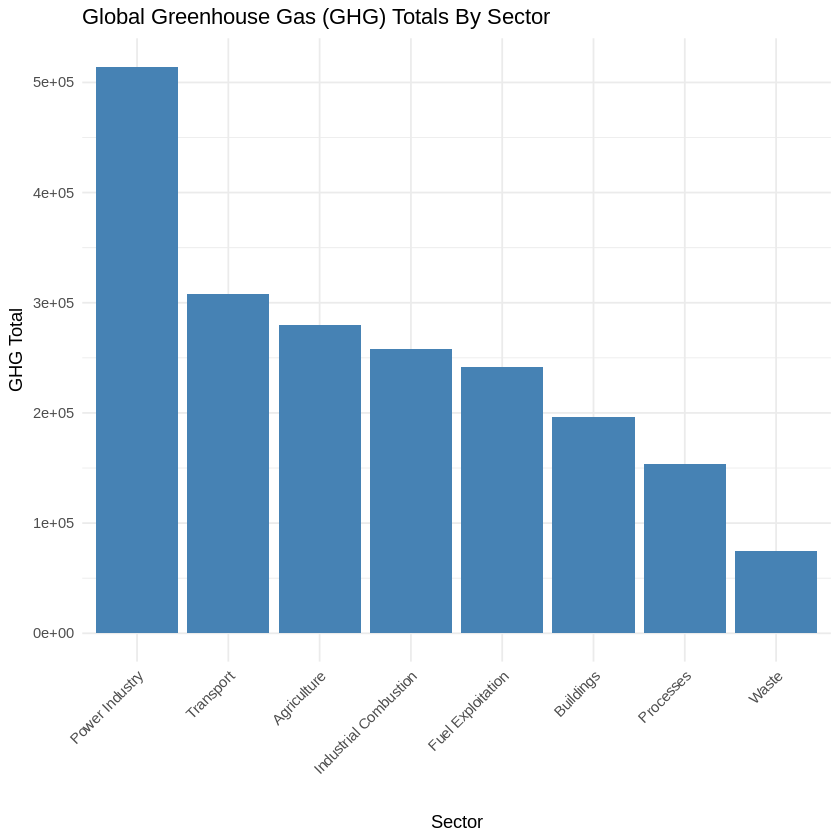

In [19]:
# Use reorder() with a negative sign to sort Sector by GHG_Total in descending order
ggplot(clean_df_top_10_sectors_by_ghg, aes(x = reorder(Sector, -GHG_Total), y = GHG_Total)) +
  geom_col(fill = "steelblue") +
  labs(
    title = "Global Greenhouse Gas (GHG) Totals By Sector",
    x = "Sector", # Manually set the label so it doesn't show "reorder(Sector, -GHG_Total)"
    y = "GHG Total"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1)
  )